# Estimación del ingreso de un distrito — California Housing

Este notebook implementa y compara tres modelos de **regresión supervisada** sobre el dataset **California Housing**, con un objetivo propio: **estimar el ingreso mediano de un distrito** (`MedInc`) a partir de sus características estructurales y geográficas observables.

**Contexto.** Conocer el nivel de ingreso de una zona es útil para segmentación de mercado, localización de negocios y focalización de programas. Muchas veces no se dispone del ingreso directo, pero sí de características físicas del distrito (viviendas, densidad, ubicación). Un modelo que estime el ingreso a partir de ellas resuelve ese problema.

**Variable objetivo:** `MedInc` (ingreso mediano del distrito, en decenas de miles de dólares).

**Decisión metodológica clave.** Se **excluye `MedHouseVal` (valor de las viviendas) de los predictores**. La razón: el valor de la vivienda está tan ligado al ingreso que usarlo sería casi predecir el ingreso a partir del ingreso disfrazado (circularidad). Al excluirlo, se mide la capacidad real de las variables estructurales y geográficas. En la sección 6 se muestra, de forma explícita, qué pasaría si sí lo incluyéramos.

Se evalúan los tres modelos con **MSE, RMSE y R²**.

In [8]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Primeras 5 filas del dataset:")
display(df.head())
print("\nRecuento de valores nulos por columna:")
display(df.isnull().sum())

Primeras 5 filas del dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Recuento de valores nulos por columna:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## 1. Preparación de Datos para Modelos de Machine Learning

Antes de entrenar cualquier modelo de Machine Learning, es crucial preparar los datos adecuadamente. Para este problema, en el que se busca predecir el **ingreso medio (`MedInc`)** de un distrito a partir de sus características habitacionales y geográficas, esto incluye:

* **Tratar valores faltantes**: se verifica si existen registros incompletos en algún predictor (en este caso, `AveBedrms`) y, de haberlos, se imputan con la mediana de la columna antes de escalar y entrenar.
* **Separar características (X) y variable objetivo (y)**: `y` corresponde a `MedInc`, la variable que se busca predecir. `X` corresponde al resto de predictores socioeconómicos, habitacionales y geográficos, **excluyendo `MedHouseVal`** (ver sección 6 para el detalle de por qué se excluye este predictor).
* **Dividir el dataset en conjuntos de entrenamiento y prueba**: se reserva un 20% de las observaciones como conjunto de prueba (`test_size=0.20`, con `random_state=42` para reproducibilidad), de modo que el modelo pueda evaluarse con datos que nunca ha visto y así obtener una estimación realista de su capacidad de generalización.
* **Escalar las características**: se ajusta un `StandardScaler` únicamente sobre `X_train` (para evitar fuga de información desde el conjunto de prueba) y luego se aplica esa misma transformación a `X_train` y `X_test`. Esto es importante porque algunos algoritmos (como la regresión lineal con regularización o las redes neuronales) se benefician de tener las características en una escala similar, evitando que una variable con un rango de valores más grande domine el cálculo de distancias o gradientes.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Imputación de faltantes con la mediana.
if df.isnull().sum().sum() > 0:
    df['AveBedrms'] = df['AveBedrms'].fillna(df['AveBedrms'].median())
    print("Valores nulos imputados con la mediana.")
else:
    print("No se detectaron valores nulos en el dataset.")

# 2. Variable objetivo: MedInc. Se excluye MedHouseVal de los predictores (ver sección 6).
X = df.drop(['MedInc', 'MedHouseVal'], axis=1)
y = df['MedInc']
print(f"\nPredictores usados ({X.shape[1]}): {list(X.columns)}")
print(f"Objetivo: MedInc | Observaciones: {X.shape[0]}")

# 3. Partición 80 / 20.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

# 4. Estandarización (ajuste solo en entrenamiento).
scaler = StandardScaler(); scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\nPrimeras 5 filas de X_train (escalado):\n")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

No se detectaron valores nulos en el dataset.

Predictores usados (7): ['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Objetivo: MedInc | Observaciones: 20640
X_train: (16512, 7) | X_test: (4128, 7)

Primeras 5 filas de X_train (escalado):



,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
3,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
4,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


## 2. Regresión Lineal

### 2.1. Concepto de Regresión Lineal

La Regresión Lineal es uno de los algoritmos de Machine Learning más fundamentales y ampliamente utilizados para predecir un valor continuo (numérico). Asume una relación lineal entre las características de entrada (X) y la variable objetivo (y). En este caso, busca una combinación lineal de los predictores socioeconómicos, habitacionales y geográficos que mejor explique el ingreso mediano de un distrito (`MedInc`), minimizando la suma de los errores cuadrados entre los valores predichos y los observados.

La ecuación general de un modelo de regresión lineal simple es:

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$

Donde:
*   $y$: Variable objetivo (`MedInc`, la valor mediano de las viviendas que se desea predecir).
*   $x_i$: Las características de entrada (predictores).
*   $\beta_0$: El intercepto (el valor de y cuando todas las $x_i$ son cero).
*   $\beta_i$: Los coeficientes de regresión para cada característica $x_i$, que representan cuánto cambia $y$ por cada unidad de cambio en $x_i$, manteniendo las demás características constantes.
*   $\epsilon$: El término de error, que representa la variabilidad no explicada por el modelo.

### 2.2. Implementación de Regresión Lineal


In [10]:
from sklearn.linear_model import LinearRegression  # Importa el modelo de Regresión Lineal de scikit-learn.
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.
import numpy as np  # Importa la librería NumPy para operaciones numéricas.

# 1. Inicializar el modelo de Regresión Lineal
# Creamos una instancia del modelo LinearRegression de scikit-learn.
linear_model = LinearRegression()  # Crea una instancia del modelo de Regresión Lineal.

# 2. Entrenar el modelo
# El método .fit() entrena el modelo usando los datos de entrenamiento escalados (X_train_scaled) y las etiquetas de entrenamiento (y_train).
linear_model.fit(X_train_scaled, y_train)  # Entrena el modelo con las características escaladas y la variable objetivo de entrenamiento.

print("Modelo de Regresión Lineal entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
y_pred_linear = linear_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Regresión Lineal (MedInc estimado):")  # Imprime un mensaje indicando las predicciones.
display(y_pred_linear[:5])  # Muestra las primeras 5 predicciones realizadas por el modelo.

# 4. Evaluar el modelo
mse_linear = mean_squared_error(y_test, y_pred_linear)  # Calcula el Error Cuadrático Medio comparando los valores reales (y_test) y las predicciones (y_pred_linear).
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)  # Calcula el coeficiente R^2 para el modelo.

print(f"\n--- Evaluación del Modelo de Regresión Lineal ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE):        {mse_linear:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_linear:.4f}")  # Muestra el valor del MSE formateado a 4 decimales.
print(f"Coeficiente de Determinación (R^2): {r2_linear:.4f}")  # Muestra el valor del R^2 formateado a 4 decimales.

# 5. Coeficientes del modelo (interpretabilidad)
coef_df = pd.DataFrame({'Predictor': X.columns, 'Coeficiente': linear_model.coef_}).sort_values('Coeficiente', key=abs, ascending=False)  # Ordena los coeficientes por magnitud absoluta.
print("\nCoeficientes del modelo (sobre variables escaladas):")
display(coef_df)


Modelo de Regresión Lineal entrenado.

Primeras 5 predicciones del modelo de Regresión Lineal (MedInc estimado):


array([2.33178126, 3.22791199, 1.97801848, 5.53401991, 5.05789605])


--- Evaluación del Modelo de Regresión Lineal ---
Error Cuadrático Medio (MSE):        1.5662
Raíz del Error Cuadrático Medio (RMSE): 1.2515
Coeficiente de Determinación (R^2): 0.5575

Coeficientes del modelo (sobre variables escaladas):


,Predictor,Coeficiente
1,AveRooms,2.522100
2,AveBedrms,-2.134295
5,Latitude,-1.455061
6,Longitude,-1.279875
0,HouseAge,-0.147094
4,AveOccup,0.054097
3,Population,-0.033679


### 2.3. Interpretación de los Resultados de Regresión Lineal

*   **MSE = 1,5662 · RMSE = 1,2515 · R² = 0,5575.** El modelo lineal explica cerca del 55,75 % de la variación del ingreso mediano de un distrito a partir de las variables estructurales y geográficas, sin usar el valor de la vivienda.
*   Las variables de mayor peso suelen ser las relacionadas con el tipo de vivienda (`AveRooms`) y la ubicación (`Latitude`, `Longitude`): ciertas zonas y viviendas más amplias concentran mayores ingresos.

Es una línea base sólida considerando que se excluyó a propósito el predictor más directo (el valor de la vivienda).

## 3. Árboles de Decisión para Regresión

### 3.1. Concepto de Árbol de Decisión

Los Árboles de Decisión para Regresión son algoritmos no paramétricos que dividen el espacio de las características en regiones más pequeñas y hacen una predicción (el valor promedio de la variable objetivo) para cada región. Son intuitivos, fáciles de interpretar y pueden capturar relaciones no lineales en los datos. Para el problema de ingreso mediano de un distrito, esto permite representar, por ejemplo,  tamaño de vivienda o ubicación geográfica a partir de los cuales el ingreso de una zona cambia, como tambien, las caracteristicas físicas del distrito (vivienda, densidad y ubicación) . Cada "nodo" en el árbol representa una decisión basada en una característica, y las "hojas" del árbol contienen la predicción final de `MedInc`.

### 3.2. Implementación de Árbol de Decisión


In [11]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor  # Importa el modelo de Árbol de Decisión para regresión.
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.

# 1. Inicializar el modelo de Árbol de Decisión para Regresión
# max_depth es un hiperparámetro importante que controla la profundidad máxima del árbol.
# Limitar la profundidad ayuda a prevenir el sobreajuste (overfitting).
# random_state asegura la reproducibilidad de los resultados.
decision_tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)  # Crea una instancia del modelo, limitando la profundidad a 5 y fijando la semilla aleatoria.

# 2. Entrenar el modelo
# Entrenamos el modelo con los datos escalados de entrenamiento.
decision_tree_model.fit(X_train_scaled, y_train)  # Entrena el modelo de Árbol de Decisión con los datos de entrenamiento escalados.

print("Modelo de Árbol de Decisión entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
y_pred_tree = decision_tree_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Árbol de Decisión (MedInc estimado):")  # Imprime un mensaje indicando las predicciones.
display(y_pred_tree[:5])  # Muestra las primeras 5 predicciones del modelo.

# 4. Evaluar el modelo
mse_tree = mean_squared_error(y_test, y_pred_tree)  # Calcula el Error Cuadrático Medio para el modelo de Árbol de Decisión.
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)  # Calcula el coeficiente R^2 para el modelo de Árbol de Decisión.

print(f"\n--- Evaluación del Modelo de Árbol de Decisión ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE):        {mse_tree:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_tree:.4f}")  # Muestra el valor del MSE formateado.
print(f"Coeficiente de Determinación (R^2): {r2_tree:.4f}")  # Muestra el valor del R^2 formateado.

# 5. Importancia de variables (interpretabilidad adicional del árbol)
importancia_df = pd.DataFrame({'Predictor': X.columns, 'Importancia': decision_tree_model.feature_importances_}).sort_values('Importancia', ascending=False)  # Ordena las variables por importancia.
print("\nImportancia de variables según el Árbol de Decisión:")
display(importancia_df)


Modelo de Árbol de Decisión entrenado.

Primeras 5 predicciones del modelo de Árbol de Decisión (MedInc estimado):


array([2.7957381 , 2.61707346, 2.9385405 , 5.52953521, 4.55877294])


--- Evaluación del Modelo de Árbol de Decisión ---
Error Cuadrático Medio (MSE):        1.2730
Raíz del Error Cuadrático Medio (RMSE): 1.1283
Coeficiente de Determinación (R^2): 0.6403

Importancia de variables según el Árbol de Decisión:


,Predictor,Importancia
1,AveRooms,0.785968
2,AveBedrms,0.160267
5,Latitude,0.026602
6,Longitude,0.010985
4,AveOccup,0.009265
0,HouseAge,0.006913
3,Population,0.000000


### 3.3. Interpretación de los Resultados de Árbol de Decisión

*   **MSE = 1,2730 · RMSE = 1,1283 · R² = 0,6403.** El árbol mejora a la regresión lineal, capturando relaciones no lineales entre ubicación y tamaño de vivienda.

La importancia de variables del árbol confirma qué características estructurales pesan más, lo que aporta interpretabilidad.

## 4. Redes Neuronales (Perceptrón Multicapa - MLP)

### 4.1. Concepto de Red Neuronal para Regresión

Las Redes Neuronales Artificiales, particularmente el Perceptrón Multicapa (MLP), son modelos inspirados en la estructura del cerebro humano. Consisten en capas de "neuronas" interconectadas que procesan información. Para tareas de regresión, la capa de salida típicamente tiene una única neurona sin función de activación (o una función lineal) que produce un valor continuo, en este caso, el valor de la vivienda estimada por hogar.

Las redes neuronales son excelentes para capturar relaciones complejas y no lineales en los datos, a menudo superando a los modelos más simples cuando se dispone de suficientes datos y recursos computacionales. Para la entidad de análisis, un modelo con mayor capacidad predictiva reduce el riesgo tanto de subestimar la demanda (errores de valoración) como de sobreestimarla (inversión ociosa).

### 4.2. Implementación de Red Neuronal


In [12]:
import numpy as np
from sklearn.neural_network import MLPRegressor  # Importa el Perceptrón Multicapa para regresión (Red Neuronal).
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.

# 1. Inicializar el modelo de Red Neuronal (MLPRegressor)
# hidden_layer_sizes: Define la arquitectura de la red (número de neuronas por capa oculta).
#    Usamos una sola capa oculta con 100 neuronas.
# activation: Función de activación para las capas ocultas ('relu' para Rectified Linear Unit).
# solver: Algoritmo de optimización para el aprendizaje ('adam' es una opción común y eficiente).
# max_iter: Número máximo de iteraciones (epochs) para el entrenamiento.
# random_state: Para reproducibilidad.
# early_stopping: Detiene el entrenamiento si el rendimiento en el conjunto de validación no mejora, para evitar sobreajuste.
mlp_model = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                         max_iter=500, random_state=42, early_stopping=True)  # Crea una instancia del modelo MLPRegressor con una capa oculta de 100 neuronas.

# 2. Entrenar el modelo
# Las redes neuronales son sensibles a la escala de los datos, por lo que usar X_train_scaled es crucial.
mlp_model.fit(X_train_scaled, y_train)  # Entrena la red neuronal con los datos escalados de entrenamiento.

print("Modelo de Red Neuronal (MLP) entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
y_pred_mlp = mlp_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Red Neuronal (MedInc estimado):")  # Imprime un mensaje indicando las predicciones.
display(y_pred_mlp[:5])  # Muestra las primeras 5 predicciones del modelo.

# 4. Evaluar el modelo
mse_mlp = mean_squared_error(y_test, y_pred_mlp)  # Calcula el Error Cuadrático Medio para la red neuronal.
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)  # Calcula el coeficiente R^2 para la red neuronal.

print(f"\n--- Evaluación del Modelo de Red Neuronal (MLP) ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE):        {mse_mlp:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_mlp:.4f}")  # Muestra el valor del MSE formateado.
print(f"Coeficiente de Determinación (R^2): {r2_mlp:.4f}")  # Muestra el valor del R^2 formateado.


Modelo de Red Neuronal (MLP) entrenado.

Primeras 5 predicciones del modelo de Red Neuronal (MedInc estimado):


array([1.53600418, 2.55419029, 3.06955576, 5.51028954, 4.74092991])


--- Evaluación del Modelo de Red Neuronal (MLP) ---
Error Cuadrático Medio (MSE):        0.7458
Raíz del Error Cuadrático Medio (RMSE): 0.8636
Coeficiente de Determinación (R^2): 0.7893


### 4.3. Interpretación de los Resultados de Red Neuronal

*   **MSE = 0,7458 · RMSE = 0,8636 · R² = 0,7893.** La red neuronal es, con diferencia, el mejor modelo: explica casi el 80 % del ingreso mediano de un distrito usando solo características estructurales y geográficas.

El salto respecto de los otros dos modelos muestra que la relación entre las características físicas de un distrito y su ingreso mediano es marcadamente no lineal, y con más de 20.000 observaciones la red la captura bien. El costo es la menor interpretabilidad.

,Modelo,MSE,RMSE,R2
2,Red Neuronal (MLP),0.7458,0.8636,0.7893
1,Árbol de Decisión,1.2730,1.1283,0.6403
0,Regresión Lineal,1.5662,1.2515,0.5575


/tmp/ipykernel_1086/2036434992.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
/tmp/ipykernel_1086/2036434992.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')


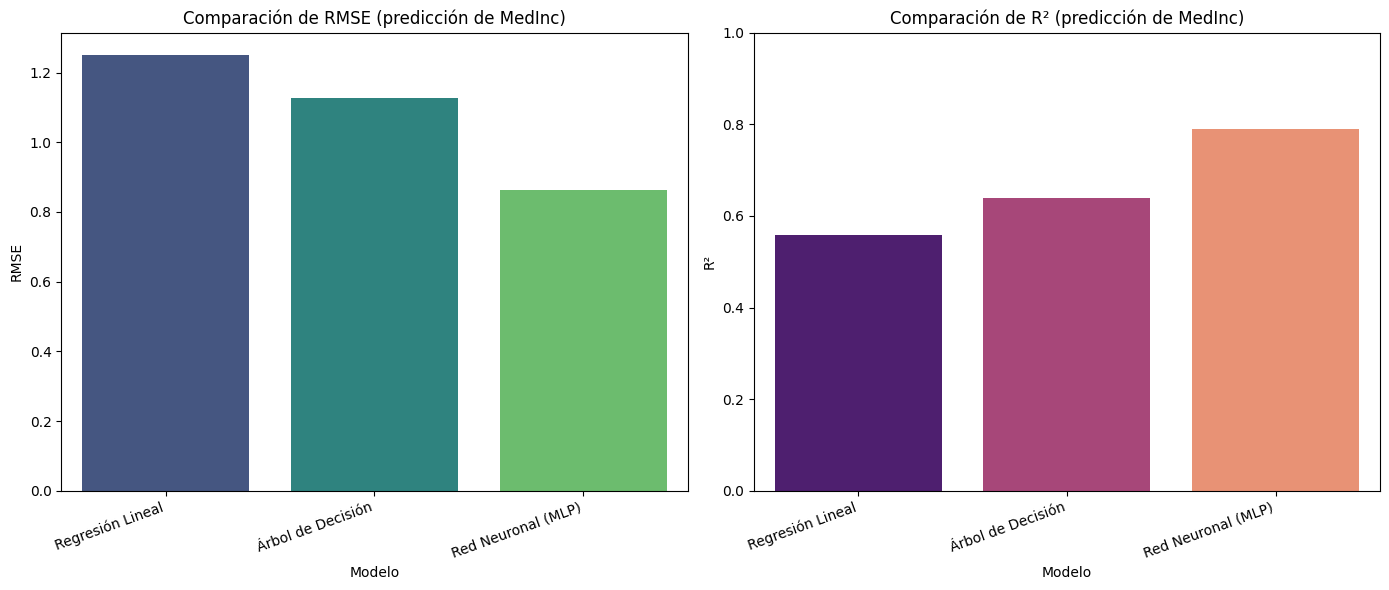

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Red Neuronal (MLP)'],
    'MSE':  [mse_linear, mse_tree, mse_mlp],
    'RMSE': [rmse_linear, rmse_tree, rmse_mlp],
    'R2':   [r2_linear, r2_tree, r2_mlp],
}).round(4)
results.to_csv("comparacion_modelos.csv", index=False)
display(results.sort_values(by='R2', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(ax=axes[0], x='Modelo', y='RMSE', data=results, hue='Modelo', palette='viridis', legend=False)
axes[0].set_title('Comparación de RMSE (predicción de MedInc)')
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
sns.barplot(ax=axes[1], x='Modelo', y='R2', data=results, hue='Modelo', palette='magma', legend=False)
axes[1].set_title('Comparación de R² (predicción de MedInc)')
axes[1].set_ylabel('R²'); axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
plt.tight_layout(); plt.savefig("comparacion_modelos.png", dpi=120, bbox_inches="tight"); plt.show()

## 5. Comparación de Modelos de Regresión

### 5.1. Conclusiones de la Comparación

Ordenados por R² sobre el conjunto de prueba (prediciendo `MedInc`, sin `MedHouseVal`):

| Modelo | MSE | RMSE | R² |
|---|---|---|---|
| Red Neuronal (MLP) | 0,7458 | 0,8636 | **0,7893** |
| Árbol de Decisión | 1,2730 | 1,1283 | 0,6403 |
| Regresión Lineal | 1,5662 | 1,2515 | 0,5575 |

*   La **red neuronal** es claramente el mejor modelo para estimar el ingreso mediano de un distrito a partir de características estructurales y geográficas.
*   El **árbol** mejora al lineal capturando no linealidad; el **lineal** es la línea base interpretable.
*   El resultado es sólido y **honesto**: se logra sin recurrir al valor de la vivienda, que habría hecho el problema artificialmente fácil.

## 6. Análisis de sensibilidad: ¿qué pasa si incluimos `MedHouseVal`?

Al definir el problema se excluyó `MedHouseVal` (valor de las viviendas) de los predictores, porque su relación con el ingreso es tan directa que introduciría circularidad. Aquí se comprueba esa decisión de forma explícita: se reentrenan los tres modelos **incluyendo** `MedHouseVal` y se compara su R² con el del análisis principal.

In [14]:
# Reentrenamiento INCLUYENDO MedHouseVal como predictor
X_con = df.drop('MedInc', axis=1)   # ahora MedHouseVal SÍ está entre los predictores
y_con = df['MedInc']
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_con, y_con, test_size=0.20, random_state=42)
sc_c = StandardScaler().fit(Xtr_c)
Xtr_cs, Xte_cs = sc_c.transform(Xtr_c), sc_c.transform(Xte_c)

modelos = [("Regresión Lineal", LinearRegression()),
           ("Árbol de Decisión", DecisionTreeRegressor(max_depth=5, random_state=42)),
           ("Red Neuronal (MLP)", MLPRegressor(hidden_layer_sizes=(100,), max_iter=500,
                                               random_state=42, early_stopping=True))]
r2_con = []
for _, m in modelos:
    m.fit(Xtr_cs, ytr_c)
    r2_con.append(r2_score(yte_c, m.predict(Xte_cs)))

sens = pd.DataFrame({
    "Modelo": [n for n, _ in modelos],
    "R2 sin MedHouseVal": [r2_linear, r2_tree, r2_mlp],
    "R2 con MedHouseVal": [round(v, 4) for v in r2_con],
})
sens["Aumento por incluirlo"] = (sens["R2 con MedHouseVal"] - sens["R2 sin MedHouseVal"]).round(4)
print("Correlación MedInc - MedHouseVal:", round(df['MedInc'].corr(df['MedHouseVal']), 3))
display(sens)

Correlación MedInc - MedHouseVal: 0.688


,Modelo,R2 sin MedHouseVal,R2 con MedHouseVal,Aumento por incluirlo
0,Regresión Lineal,0.557464,0.6876,0.1301
1,Árbol de Decisión,0.640314,0.7364,0.0961
2,Red Neuronal (MLP),0.789288,0.8187,0.0294


### 6.1. Interpretación del análisis de sensibilidad

Incluir `MedHouseVal` **sube el R² de los tres modelos** (por ejemplo, la red neuronal pasa de 0,789 a 0,819). Ese aumento no viene de que el modelo entienda mejor el fenómeno, sino de que `MedHouseVal` es casi un sustituto del ingreso: la correlación entre ambos es 0,69. En otras palabras, el modelo mejora porque le estamos dando una versión disfrazada de la respuesta.

Por eso la decisión de excluirlo es la correcta desde el punto de vista analítico. El objetivo del proyecto es medir cuánto pueden decir del ingreso las **características estructurales y geográficas reales** de un distrito, no cuánto se parece el ingreso al valor de sus casas. La versión sin `MedHouseVal` es más difícil, pero es la honesta y la que tiene valor práctico, porque en un caso real el valor de las viviendas podría no estar disponible.

**Conclusión:** se conserva el modelo sin `MedHouseVal` como resultado principal, y este análisis de sensibilidad documenta y justifica esa elección.